# NB06: Prebiotic Pairing

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Test H4 — identify prebiotics that selectively boost probiotics over PA14.

Carbon sources where commensals grow well but PA14 does not can serve as prebiotics — giving probiotics a biomass head-start before niche competition begins.

**Input**: `data/formulations_ranked.tsv` (NB05), `data/isolate_master.tsv`, `~/protect/gold/dim_candidate_prebiotics`  
**Output**: `data/prebiotic_pairings.tsv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
GOLD = Path.home() / 'protect' / 'gold'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

master = pd.read_csv(DATA / 'isolate_master.tsv', sep='\t')
formulations = pd.read_csv(DATA / 'formulations_ranked.tsv', sep='\t')
prebiotics = pd.read_parquet(GOLD / 'dim_candidate_prebiotics.snappy.parquet')
cu = pd.read_parquet(GOLD / 'fact_carbon_utilization.snappy.parquet')

print(f'Master: {len(master)} isolates')
print(f'Formulations: {len(formulations)}')
print(f'Prebiotics table: {len(prebiotics)} entries')

# Ensure master carbon cols are numeric
carbon_sources_list = ['glucose', 'lactate', 'serine', 'threonine', 'alanine', 'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate', 'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine', 'arginine', 'ornithine', 'cystein', 'methionine']
for col in carbon_sources_list:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')


Master: 429 isolates
Formulations: 22389
Prebiotics table: 431 entries


## 1. Selectivity Analysis: Which Carbon Sources Favor Commensals Over PA14?

In [2]:
carbon_sources = ['glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

# Convert ALL columns to numeric
for col in carbon_sources:
    cu[col] = pd.to_numeric(cu[col], errors='coerce')
    master[col] = pd.to_numeric(master[col], errors='coerce') if col in master.columns else None

pa14_cu = cu[cu.asma_id.str.contains('PA14', case=False, na=False)]
pa14_mean = pa14_cu[carbon_sources].mean()

# Safe isolates (from scores file)
scores_df = pd.read_csv(DATA / 'single_isolate_scores.tsv', sep='\t')
safe_ids = scores_df[scores_df.is_safe == True].asma_id.values
safe_cu = cu[cu.asma_id.isin(safe_ids)].copy()
safe_mean = safe_cu.groupby('asma_id')[carbon_sources].mean()
commensal_mean = safe_mean.mean()

selectivity = pd.DataFrame({
    'pa14_od': pa14_mean,
    'commensal_mean_od': commensal_mean,
    'selectivity_ratio': commensal_mean / (pa14_mean + 0.01),
    'pa14_can_use': pa14_mean > 0.1,
    'commensal_fraction_using': (safe_mean > 0.1).mean()
}).sort_values('selectivity_ratio', ascending=False)

print('Carbon Source Selectivity (higher = better prebiotic for commensals):')
print(selectivity.round(3).to_string())

good_prebiotics = selectivity[(selectivity.selectivity_ratio > 1.5) & (~selectivity.pa14_can_use)]
print(f'\nBest prebiotic candidates: {good_prebiotics.index.tolist()}')


Carbon Source Selectivity (higher = better prebiotic for commensals):
               pa14_od  commensal_mean_od  selectivity_ratio  pa14_can_use  commensal_fraction_using
cystein          0.060              0.067              0.959         False                     0.114
threonine        0.053              0.050              0.789         False                     0.008
methionine       0.054              0.049              0.769         False                     0.003
serine           0.062              0.050              0.699         False                     0.016
glycine          0.072              0.050              0.603         False                     0.016
valine           0.106              0.054              0.463          True                     0.039
phenylalanine    0.118              0.053              0.413          True                     0.034
tryptophan       0.153              0.052              0.323          True                     0.023
glucose          0.21

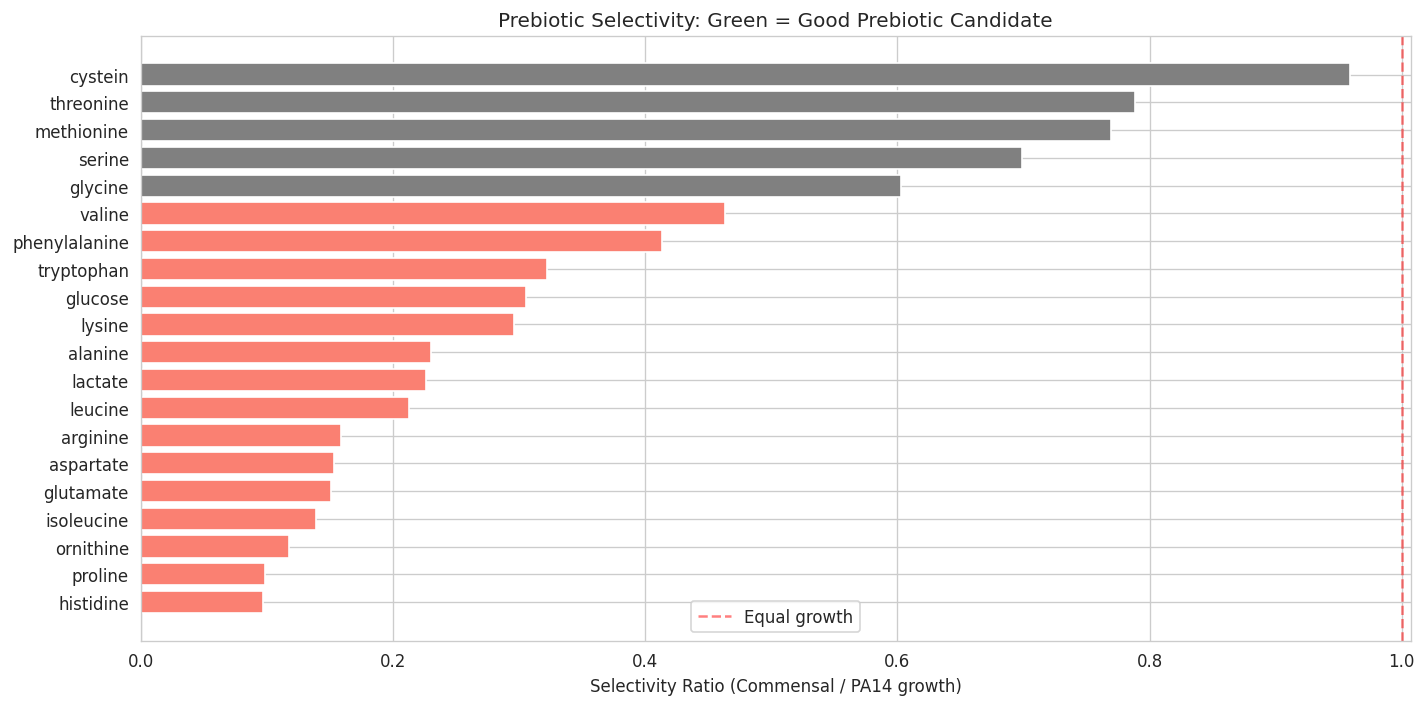


Best prebiotic candidates (selectivity > 1.5 AND PA14 cannot use):
Empty DataFrame
Columns: [pa14_od, commensal_mean_od, selectivity_ratio, pa14_can_use, commensal_fraction_using]
Index: []


In [3]:
# Visualization: selectivity plot
fig, ax = plt.subplots(figsize=(12, 6))
sel = selectivity.sort_values('selectivity_ratio', ascending=True)
colors = ['green' if r > 2 and not sel.loc[sub, 'pa14_can_use'] else 
          'lightgreen' if r > 1.5 else 
          'salmon' if sel.loc[sub, 'pa14_can_use'] else 'grey'
          for sub, r in zip(sel.index, sel.selectivity_ratio)]
ax.barh(range(len(sel)), sel.selectivity_ratio, color=colors)
ax.set_yticks(range(len(sel)))
ax.set_yticklabels(sel.index)
ax.axvline(1, color='red', ls='--', alpha=0.5, label='Equal growth')
ax.set_xlabel('Selectivity Ratio (Commensal / PA14 growth)')
ax.set_title('Prebiotic Selectivity: Green = Good Prebiotic Candidate')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '06_prebiotic_selectivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify best prebiotic candidates
good_prebiotics = selectivity[(selectivity.selectivity_ratio > 1.5) & (~selectivity.pa14_can_use)]
print(f'\nBest prebiotic candidates (selectivity > 1.5 AND PA14 cannot use):')
print(good_prebiotics.round(3).to_string())

## 2. Cross-Reference with Candidate Prebiotics Table

In [4]:
# Examine the dim_candidate_prebiotics table
prebiotics['rs_diff'] = pd.to_numeric(prebiotics['rs_diff'], errors='coerce')
prebiotics['log2fc'] = pd.to_numeric(prebiotics['log2fc'], errors='coerce')
print(f'Prebiotic candidates: {len(prebiotics)} entries')
print(f'Species: {prebiotics.species.nunique()}')
print(f'Samples: {prebiotics["sample"].nunique()}')
print(f'Unique gene/pathway names: {prebiotics.name.nunique()}')
print(f'\nTop species by prebiotic enrichment (mean rs_diff):')
sp_enrich = prebiotics.groupby('species')['rs_diff'].agg(['mean','count']).sort_values('mean', ascending=False)
print(sp_enrich.head(15).round(2).to_string())
print(f'\nTop prebiotic gene targets (by mean log2fc):')
gene_enrich = prebiotics.groupby('name')['log2fc'].agg(['mean','count']).sort_values('mean', ascending=False)
print(gene_enrich.head(15).round(2).to_string())


Prebiotic candidates: 431 entries
Species: 35
Samples: 20
Unique gene/pathway names: 107

Top species by prebiotic enrichment (mean rs_diff):
                               mean  count
species                                   
Achromobacter xylosoxidans   144.15     34
Prevotella nanceiensis        49.60      2
Capnocytophaga sputigena      45.75      2
Bifidobacterium breve         40.99      5
Streptococcus oralis_E        32.76     10
Streptococcus salivarius      28.07     57
Streptococcus parasanguinis   23.46     29
Rothia sp001808955            22.15     40
Veillonella atypica           17.91      7
Veillonella parvula           17.58     13
Staphylococcus aureus         15.61     13
Streptococcus thermophilus    14.08     32
Prevotella melaninogenica     12.36     16
Streptococcus mitis_AR        12.17      7
Prevotella denticola          11.43      4

Top prebiotic gene targets (by mean log2fc):
                                                                 mean  count
name

## 3. Pair Prebiotics with Top Formulations

In [5]:
# For each top formulation, find the best prebiotic
prebiotic_subs = good_prebiotics.index.tolist() if len(good_prebiotics) > 0 else selectivity.nlargest(5, 'selectivity_ratio').index.tolist()

pairings = []
for k in range(1, 6):
    top_form = formulations[formulations.k == k].nlargest(3, 'composite_score')
    for _, form in top_form.iterrows():
        member_ids = form.isolates.split(',')
        members = master[master.asma_id.isin(member_ids)]
        
        # For each prebiotic candidate, compute how well this formulation uses it
        for sub in prebiotic_subs:
            member_growth = pd.to_numeric(members[sub], errors='coerce').mean() if sub in members.columns else 0
            pairings.append({
                'formulation_k': k,
                'formulation_score': form.composite_score,
                'species': form.species,
                'prebiotic': sub,
                'member_growth_on_prebiotic': member_growth,
                'pa14_growth_on_prebiotic': pa14_mean.get(sub, 0),
                'selectivity': selectivity.loc[sub, 'selectivity_ratio'] if sub in selectivity.index else 0
            })

pairings_df = pd.DataFrame(pairings)
pairings_df['prebiotic_advantage'] = pairings_df.member_growth_on_prebiotic - pairings_df.pa14_growth_on_prebiotic

# Best pairing per formulation
best_pairings = pairings_df.loc[pairings_df.groupby(['formulation_k', 'species'])['prebiotic_advantage'].idxmax()]
print('Best prebiotic for each top formulation:')
print(best_pairings[['formulation_k', 'species', 'prebiotic', 'member_growth_on_prebiotic',
                      'pa14_growth_on_prebiotic', 'prebiotic_advantage']].round(3).to_string(index=False))

Best prebiotic for each top formulation:
 formulation_k                                                                                                                         species prebiotic  member_growth_on_prebiotic  pa14_growth_on_prebiotic  prebiotic_advantage
             1                                                                                                        Leclercia adecarboxylata   cystein                       0.056                      0.06               -0.004
             1                                                                                                                Neisseria mucosa   cystein                       0.103                      0.06                0.042
             1                                                                                                          Pseudomonas_E juntendi   cystein                       0.356                      0.06                0.296
             2                                 

In [6]:
# Save
pairings_df.to_csv(DATA / 'prebiotic_pairings.tsv', sep='\t', index=False)
selectivity.to_csv(DATA / 'carbon_selectivity.tsv', sep='\t')

print(f'Saved: {DATA}/prebiotic_pairings.tsv ({len(pairings_df)} pairings)')
print(f'Saved: {DATA}/carbon_selectivity.tsv ({len(selectivity)} substrates)')

print(f'\n=== NB06 SUMMARY ===')
print(f'Carbon sources analyzed: {len(carbon_sources)}')
print(f'Good prebiotic candidates (selectivity>1.5, PA14 cannot use): {len(good_prebiotics)}')
if len(good_prebiotics) > 0:
    print(f'Best prebiotics: {good_prebiotics.index.tolist()}')

Saved: ../data/prebiotic_pairings.tsv (75 pairings)
Saved: ../data/carbon_selectivity.tsv (20 substrates)

=== NB06 SUMMARY ===
Carbon sources analyzed: 20
Good prebiotic candidates (selectivity>1.5, PA14 cannot use): 0
